In [ ]:
!pip install tensorflow --upgrade

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# get the data from computer
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
!unzip /content/archive.zip

In [ ]:
from re import A
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import shutil
import glob

In [ ]:
# count the number of images in the respective classes 0 - Brain Tumor 1 - No Brain Tumor
ROOT_DIR = "/content/Training"
number_of_images = {}

for dir in os.listdir(ROOT_DIR):
  number_of_images[dir] = len(os.listdir(os.path.join(ROOT_DIR, dir)))

In [ ]:
number_of_images.items()

dict_items([('notumor', 1595), ('meningioma', 1339), ('glioma', 1321), ('pituitary', 1457)])

# we will split the data such that
- 70% for Training Data
- 30% for Validation




In [ ]:
# we will create a train folder
healthy_path = '/content/train/Healthy'
tumor_path = '/content/train/Brain Tumor'

# Create the directories
os.makedirs('/content/train', exist_ok=True)
os.makedirs(healthy_path, exist_ok=True)
os.makedirs(tumor_path, exist_ok=True)

# Classes that belong to 'tumor'
tumor_classes = ['glioma', 'meningioma', 'pituitary']

for folder in os.listdir(ROOT_DIR):
  folder_path = os.path.join(ROOT_DIR, folder)
  if os.path.isdir(folder_path):
    target_path = tumor_path if folder in tumor_classes else healthy_path
    # Get all files in the folder
    files = os.listdir(folder_path)

    # Randomly select 70% of the files
    num_files_to_select = int(0.7 * len(files))
    selected_files = np.random.choice(files, num_files_to_select, replace=False)

    # Copy the selected files to the appropriate folder
    for file in selected_files:
      file_path = os.path.join(folder_path, file)
      if os.path.isfile(file_path):  # Ensure it's a file
        shutil.copy(file_path, target_path)

In [ ]:
# Check to verify if data has been sent correctly
number_of_images_train = {}

for dir in os.listdir('/content/train'):
  number_of_images_train[dir] = len(os.listdir(os.path.join('/content/train', dir)))

number_of_images_train.items()

dict_items([('Brain Tumor', 2880), ('Healthy', 1116)])

In [ ]:
# we will create a validation folder
healthy_path = '/content/val/Healthy'
tumor_path = '/content/val/Brain Tumor'

# Create the directories
os.makedirs('/content/val', exist_ok=True)
os.makedirs(healthy_path, exist_ok=True)
os.makedirs(tumor_path, exist_ok=True)

# Classes that belong to 'tumor'
tumor_classes = ['glioma', 'meningioma', 'pituitary']

for folder in os.listdir(ROOT_DIR):
  folder_path = os.path.join(ROOT_DIR, folder)
  if os.path.isdir(folder_path):
    target_path = tumor_path if folder in tumor_classes else healthy_path
    # Get all files in the folder
    files = os.listdir(folder_path)

    # Randomly select 30% of the files
    num_files_to_select = int(0.3 * len(files))
    selected_files = np.random.choice(files, num_files_to_select, replace=False)

    # Copy the selected files to the appropriate folder
    for file in selected_files:
      file_path = os.path.join(folder_path, file)
      if os.path.isfile(file_path):  # Ensure it's a file
        shutil.copy(file_path, target_path)

In [ ]:
# we will create a test folder
TEST_DIR = '/content/Testing'

healthy_path = '/content/test/Healthy'
tumor_path = '/content/test/Brain Tumor'

# Create the directories
os.makedirs('/content/test', exist_ok=True)
os.makedirs(healthy_path, exist_ok=True)
os.makedirs(tumor_path, exist_ok=True)

# Classes that belong to 'tumor'
tumor_classes = ['glioma', 'meningioma', 'pituitary']

for folder in os.listdir(TEST_DIR):
  folder_path = os.path.join(TEST_DIR, folder)
  if os.path.isdir(folder_path):
    target_path = tumor_path if folder in tumor_classes else healthy_path
# Copy all files to the appropriate folder
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if os.path.isfile(file_path):  # Ensure it's a file
            shutil.copy(file_path, target_path)

# Model Build

In [ ]:
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense, BatchNormalization, GlobalAvgPool2D
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import keras

In [ ]:
# CNN Model

model = Sequential()

model.add(Conv2D(filters= 16 , kernel_size= (3, 3), activation = 'relu', input_shape = (224,224,3) ))

model.add(Conv2D(filters= 36 , kernel_size= (3, 3), activation = 'relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters= 64 , kernel_size= (3, 3), activation = 'relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Dropout(rate= 0.25))

model.add(Flatten())
model.add(Dense(units=64, activation= 'relu'))
model.add(Dropout(rate= 0.25 ))
model.add(Dense(units= 1, activation= 'sigmoid'))

model.summary()

In [ ]:
model.compile(optimizer='adam', loss= keras.losses.binary_crossentropy, metrics=['accuracy'])

# Preparing our data using Data Generator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.mobilenet import preprocess_input

In [ ]:
def preprocessingImages(path):
  image_data = ImageDataGenerator(zoom_range=0.2, shear_range= 0.2, preprocessing_function= preprocess_input, horizontal_flip= True)
  image = image_data.flow_from_directory(directory = path, target_size = (224, 224), batch_size = 32, class_mode = 'binary')

  return image

In [ ]:
path = "/content/train"
train_data = preprocessingImages(path)

Found 3996 images belonging to 2 classes.


In [ ]:
def preprocessingImages2(path):
  image_data = ImageDataGenerator(preprocessing_function= preprocess_input)
  image = image_data.flow_from_directory(directory = path, target_size = (224, 224), batch_size = 32, class_mode = 'binary')

  return image

In [ ]:
path = "/content/test"
test_data = preprocessingImages2(path)

Found 1311 images belonging to 2 classes.


In [ ]:
path = "/content/val"
val_data = preprocessingImages2(path)

Found 1712 images belonging to 2 classes.


In [ ]:
# Early stopping and model check point

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# early stopping

es = EarlyStopping(monitor="val_accuracy", min_delta= 0.01, patience= 3, verbose= 1, mode = 'auto')

# model check point

mc = ModelCheckpoint(monitor="val_accuracy",filepath="./bestmodel.keras", verbose= 1, save_best_only= True, mode = 'auto')

cd = [es,mc]

# Model Training

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Flatten, Dense
from keras.models import Model, load_model
from keras.applications.mobilenet import MobileNet, preprocess_input
import keras

In [ ]:
base_model = MobileNet(input_shape= (224, 224, 3), include_top= False)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
for layer in base_model.layers:
  layer.trainable = False

In [ ]:
x = Flatten()(base_model.output)
x = Dense(units=1 , activation= 'sigmoid')(x)

model = Model(base_model.input, x)


In [ ]:
model.summary()

In [ ]:
model.compile(optimizer='rmsprop', loss = keras.losses.binary_crossentropy, metrics=['accuracy'])

In [ ]:
## Call Back

from keras.callbacks import ModelCheckpoint, EarlyStopping

mc = ModelCheckpoint(filepath="./bestmodel.keras", monitor="val_accuracy",verbose= 1, save_best_only= True)

es = EarlyStopping(monitor="val_accuracy",min_delta= 0.01, patience= 3, verbose= 1)

cb = [mc,es]

In [ ]:
hist = model.fit(train_data, steps_per_epoch= 10, epochs= 30, validation_data= val_data, validation_steps= 16, callbacks= cb)

In [ ]:
# load the best fit model

model = load_model("/content/bestmodel.keras")

In [ ]:
acc = model.evaluate(test_data)[1]

print(f"the accuracy of our model is {acc*100}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9579 - loss: 0.3818
the accuracy of our model is 95.95728516578674


In [ ]:
# Standard Model without any transfer learning and CNN architecture
# hs = model.fit(train_data, steps_per_epoch= 8, epochs= 30, verbose= 1, validation_data= val_data, validation_steps= 16, callbacks=cd)

In [ ]:
# Model Graphical Interpretation

h = hs.history
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

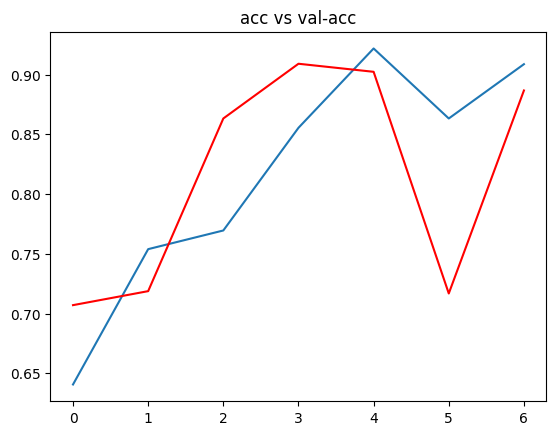

In [ ]:
import matplotlib.pyplot as plt

plt.plot(h["accuracy"])
plt.plot(h["val_accuracy"], c = "red")

plt.title("acc vs val-acc")
plt.show()

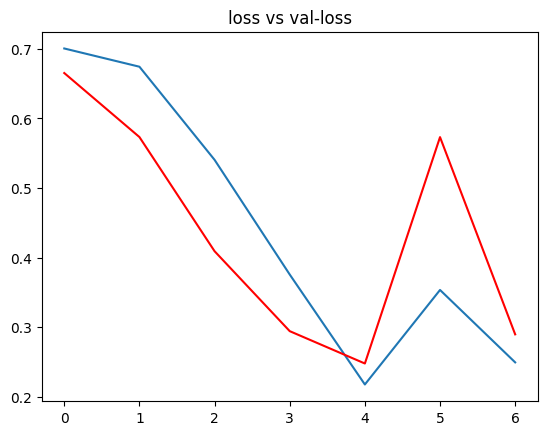

In [ ]:
import matplotlib.pyplot as plt

plt.plot(h["loss"])
plt.plot(h["val_loss"], c = "red")

plt.title("loss vs val-loss")
plt.show()

In [ ]:
# Model Accuracy
from keras.models import load_model

model = load_model("/content/bestmodel.keras")

# Model Accuracy

In [ ]:
from keras.preprocessing.image import load_img, img_to_array

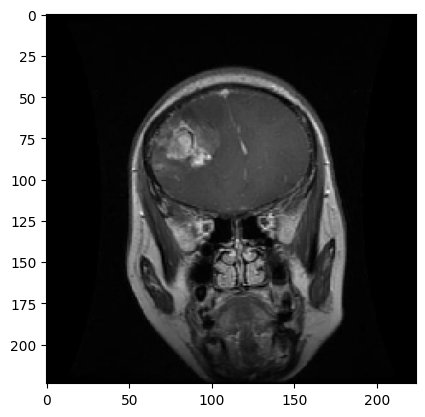

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
The person has brain tumor


In [ ]:
path = "/content/Training/glioma/Tr-glTr_0000.jpg"

img = load_img(path, target_size= (224, 224))
input_arr = img_to_array(img)/255

plt.imshow(input_arr)
plt.show()

input_arr.shape

input_arr = np.expand_dims(input_arr, axis = 0)

pred = model.predict(input_arr)[0][0]
pred

pred_class = 1 if pred >= 0.5 else 0

if pred_class == 0:
  print("The person has brain tumor")
else:
  print("The person does not have brain tumor")


In [ ]:
train_data.class_indices

{'Brain Tumor': 0, 'Healthy': 1}